# Repressilator

$$
\lambda CI \dashv LacI \dashv TetR \dashv \lambda CI
$$

Each Component has an mRNA and a Protein, hence the equations are:

$$\begin{aligned}
\frac{dm_i}{dt} &= -m_i + \frac{\alpha}{1+P_j^n} + \alpha_0 \\[1.5ex]
\frac{dP_i}{dt} &= -\beta (P_i - m_i)
\end{aligned}$$
 
Where: <br>
i = {LCI, LacI, TetR}, j = {TetR, LCI, LacI} <br>
and: <br>
m = concentration of mRNA <br>
P = concentration of protein <br>
$\alpha$ = max production rate <br>
$\alpha_0$ = basal transcription rate <br>
$n$ = hill coeficient <br>
$\beta$ = protein decay

# GFP as observable

$$
R_n G \xrightleftharpoons[k_e]{k_d} nR + G \xrightarrow{k_g} G + mRNA \xrightarrow{k_m} G + mRNA + P
$$

Where R is $P_{TetR}$ and P is GFP. mRNA decays at rate $d_1$ and P at rate $d_2$. <br>

Hence, the equations are: <br>

$$\begin{aligned}
\frac{dRNA}{dt} &= k_g G - d_1 mRNA\\
\frac{dP}{dt} &= k_m mRNA - d_2 P\\
\end{aligned}$$

To deal with G we assume that $G_T = G + R_nG$ ($R_nG = G_T - G$), hence we can derive: <br>

$$\begin{aligned}
\frac{dG}{dt} &= k_d R_nG - k_e G \cdot R^n = 0 \\

k_d R_nG &= k_e G \cdot R^n \\
k_d G_T - k_d G  &= k_e G \cdot R^n \\
k_dG_T &= k_e G \cdot R^n  +  k_d G = G \cdot (k_e R^n + k_d) \\
G &= \frac{k_d G_T}{k_e R^n + k_d} = \frac{G_T}{K_R R^n + 1}; where \; K_R = k_e/k_d \\

\end{aligned}$$

Hence, the mRNA equation for GFP is: 

$$\begin{aligned}
\frac{dRNA}{dt} &= \frac{k_g G_T}{1 + K_R R^n} - d_1 mRNA = \frac{\alpha_{GFP}}{1 + K_R R^n} - d_1 mRNA\\
\end{aligned}$$

# Import Libraries

In [219]:
import jax
import jax.numpy as jnp
import diffrax
import equinox as eqx
import lineax as lx
import optimistix as optx
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import random
import time
import os 
from tkinter import simpledialog
from operator import contains
from tkinter.filedialog import askdirectory
import tkinter as tk
from ipywidgets import interact, widgets, fixed, interactive, HBox, Layout, VBox
import pickle
import matplotlib as mpl
import pandas as pd

# Functions

In [ ]:
# Basic model for the repressilator
def Repressilator_Basic(t, y, *theta):
    mI, mL, mT, pI, pL, pT = y
    alpha_0, alpha, beta, n = theta

    dmIdt = -mI + (alpha/(1+pT**n)) + alpha_0
    dmLdt = -mL + (alpha/(1+pI**n)) + alpha_0
    dmTdt = -mT + (alpha/(1+pL**n)) + alpha_0

    dpIdt = -beta * (pI - mI)
    dpLdt = -beta * (pL - mL)
    dpTdt = -beta * (pT - mT)

    return [dmIdt, dmLdt, dmTdt, dpIdt, dpLdt, dpTdt]

# Model for the repressilator with GFP as observable
def Repressilator_GFP(t, y, *theta):
    mI, mL, mT, pI, pL, pT,   mG, pG = y
    alpha_0, alpha, beta, n ,   alpha_GFP, kR, kM, n2, d1, d2= theta

    dmIdt = -mI + (alpha/(1+pT**n)) + alpha_0
    dmLdt = -mL + (alpha/(1+pI**n)) + alpha_0
    dmTdt = -mT + (alpha/(1+pL**n)) + alpha_0

    dpIdt = -beta * (pI - mI)
    dpLdt = -beta * (pL - mL)
    dpTdt = -beta * (pT - mT)

    dmGdt = (alpha_GFP/(1+kR*pT**n2)) - d1*mG
    dpGdt = kM*mG - d2*pG

    return [dmIdt, dmLdt, dmTdt, dpIdt, dpLdt, dpTdt,   dmGdt, dpGdt]

# Simulate repressilator model in batch in a CPU
def simRep_CPU(ths, y0, tspan, teval):

    if np.shape(y0)[1] == 6:
        fn = Repressilator_Basic
    else:
        fn = Repressilator_GFP

    sims = np.zeros((np.shape(ths)[0], len(teval), np.shape(y0)[1]))

    for i in range(np.shape(ths)[0]):

        params = ths[i,::]
        y00 = y0[i,::]
        sol = solve_ivp(
            fun=fn,
            t_span=tspan,
            y0=y00,
            t_eval=teval,
            args=tuple(params),
            method='BDF'  # Use 'Radau' or 'BDF' if the system is stiff
        )

        for j in range(len(y00)):
            sims[i,::,j] = sol.y[j]

    return sims

# Plot the repressilator model
def plotRepres(teval, sims):

    if np.shape(sims)[2] == 6:
        fig, ax = plt.subplots(2,1, figsize=(10, 5))
    elif np.shape(sims)[2] == 8:
        fig, ax = plt.subplots(3,1, figsize=(10, 5))


    for i in range(np.shape(sims)[0]):

        lbl_CI = r'$\lambda CI$' if i == 0 else None
        lbl_LacI = r'$LacI$' if i == 0 else None
        lbl_TetR = r'$TetR$' if i == 0 else None
        lbl_GFP1 = r'$mRNA$' if i == 0 else None
        lbl_GFP2 = r'$Protein$' if i == 0 else None

        ax[0].plot(teval, sims[i,::,0], label=lbl_CI, c='#12988d', alpha = 0.4)
        ax[0].plot(teval, sims[i,::,1], label=lbl_LacI, c="#981250", alpha = 0.4)
        ax[0].plot(teval, sims[i,::,2], label=lbl_TetR, c="#8f9812", alpha = 0.4)

        ax[1].plot(teval, sims[i,::,3], label=lbl_CI, c='#12988d', alpha = 0.4)
        ax[1].plot(teval, sims[i,::,4], label=lbl_LacI, c="#981250", alpha = 0.4)
        ax[1].plot(teval, sims[i,::,5], label=lbl_TetR, c="#8f9812", alpha = 0.4)

        if np.shape(sims)[2] == 8:
            ax[2].plot(teval, sims[i,::,6], label=lbl_GFP1, c="#98128D", alpha = 0.4)
            ax[2].plot(teval, sims[i,::,7], label=lbl_GFP2, c="#129819", alpha = 0.4)

    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].set_ylabel('mRNA')
    ax[0].legend()
    ax[0].set_title('Repressilator')

    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    if np.shape(sims)[2] == 6:
        ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Protein')
    ax[1].legend()

    if np.shape(sims)[2] == 8:
        ax[2].spines['top'].set_visible(False)
        ax[2].spines['right'].set_visible(False)
        ax[2].set_xlabel('Time')
        ax[2].set_ylabel('GFP')
        ax[2].legend()

    
    plt.show()

# Plot represilator model for interactive plot where you can modify parameter and initial states
def plotRepress_Single(tspan, teval, t1,t2,t3,t4, m1,m2,m3,p1,p2,p3):

    params = [t1,t2,t3,t4]
    y0 = [m1,m2,m3,p1,p2,p3]
    
    sims = np.zeros((1, len(teval), len(y0)))
    
    sol = solve_ivp(
        fun=Repressilator_Basic,
        t_span=tspan,
        y0=y0,
        t_eval=teval,
        args=tuple(params),
        method='BDF'  # Use 'Radau' or 'BDF' if the system is stiff
    )

    for j in range(len(y0)):
        sims[0,::,j] = sol.y[j]

    plotRepres(teval, sims)

# Display interactive plot for plotRepress_Single function
def playRepress(tspan, teval):
    # 1. Define individual slider widgets
    t1 = widgets.FloatSlider(min=0, max=2, step=1e-5, value=1e-1, readout=True, description=r'alpha_0', layout=Layout(width='400px'))
    t2 = widgets.FloatSlider(min=0, max=100, step=1e-5, value=70, readout=True, description=r'alpha', layout=Layout(width='400px'))
    t3 = widgets.FloatSlider(min=0, max=10, step=1e-5, value=0.32, readout=True, description=r'beta', layout=Layout(width='400px'))
    t4 = widgets.FloatSlider(min=0, max=10, step=1e-5, value=2, readout=True, description=r'n', layout=Layout(width='400px'))

    m1 = widgets.FloatSlider(min=0, max=100, step=1e-5, value=42, readout=True, description=r'mRNA ICI', layout=Layout(width='400px'))
    m2 = widgets.FloatSlider(min=0, max=100, step=1e-5, value=22, readout=True, description=r'mRNA LacI', layout=Layout(width='400px'))
    m3 = widgets.FloatSlider(min=0, max=100, step=1e-5, value=6, readout=True, description=r'mRNA TetR', layout=Layout(width='400px'))

    p1 = widgets.FloatSlider(min=0, max=100, step=1e-5, value=40, readout=True, description=r'Prot ICI', layout=Layout(width='400px'))
    p2 = widgets.FloatSlider(min=0, max=100, step=1e-5, value=15, readout=True, description=r'Prot LacI', layout=Layout(width='400px'))
    p3 = widgets.FloatSlider(min=0, max=100, step=1e-5, value=40, readout=True, description=r'Prot TetR', layout=Layout(width='400px'))



    # 2. Group widgets into two vertical columns (VBox)
    col1 = VBox([t1, t2,  m1,m2,m3])
    col2 = VBox([t3, t4,  p1,p2,p3])

    # 3. Place columns side-by-side in a horizontal box (HBox)
    controls = HBox([col1, col2])

    # 4. Bind widgets and fixed parameters to the callback function
    out = widgets.interactive_output(
        plotRepress_Single,
        {
            'tspan': fixed(tspan),
            'teval': fixed(teval),
            't1': t1,
            't2': t2,
            't3': t3,
            't4': t4,
            'm1': m1,
            'm2': m2,
            'm3': m3,
            'p1': p1,
            'p2': p2,
            'p3': p3,
        }
    )

    # 5. Display controls on top and the plot output below
    display(controls, out)

##################### HERE IS FOR THINGS USING GPU
def Repressilator_Basic_GPU(t, y, theta):
    mI, mL, mT, pI, pL, pT = y
    alpha_0, alpha, beta, n = theta

    dmIdt = -mI + (alpha/(1+pT**n)) + alpha_0
    dmLdt = -mL + (alpha/(1+pI**n)) + alpha_0
    dmTdt = -mT + (alpha/(1+pL**n)) + alpha_0

    dpIdt = -beta * (pI - mI)
    dpLdt = -beta * (pL - mL)
    dpTdt = -beta * (pT - mT)

    return jnp.stack([dmIdt, dmLdt, dmTdt, dpIdt, dpLdt, dpTdt])

# Model for the repressilator with GFP as observable
def Repressilator_GFP_GPU(t, y, theta):
    mI, mL, mT, pI, pL, pT,   mG, pG = y
    alpha_0, alpha, beta, n ,   alpha_GFP, kR, kM, n2, d1, d2= theta

    dmIdt = -mI + (alpha/(1+pT**n)) + alpha_0
    dmLdt = -mL + (alpha/(1+pI**n)) + alpha_0
    dmTdt = -mT + (alpha/(1+pL**n)) + alpha_0

    dpIdt = -beta * (pI - mI)
    dpLdt = -beta * (pL - mL)
    dpTdt = -beta * (pT - mT)

    dmGdt = (alpha_GFP/(1+kR*pT**n2)) - d1*mG
    dpGdt = kM*mG - d2*pG

    return jnp.stack([dmIdt, dmLdt, dmTdt, dpIdt, dpLdt, dpTdt,   dmGdt, dpGdt])

@jax.jit
def run_batch(batch_params, batch_y0, tspan):
    def solve_single_ode(params, y0):
        term = diffrax.ODETerm(Repressilator_Basic_GPU)
        solver = diffrax.Kvaerno5()

        solution = diffrax.diffeqsolve(
            term,
            solver,
            t0=tspan[0],
            t1=tspan[1],
            dt0=0.01,
            y0=y0,
            args=params,
            saveat=diffrax.SaveAt(ts=jnp.linspace(tspan[0], tspan[1], 500)),
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            max_steps=65536
        )
        return solution.ys

    # Vectorize across the 0th axis of both batch_params and batch_y0
    return jax.vmap(solve_single_ode)(batch_params, batch_y0)

@jax.jit
def run_batch_GFP(batch_params, batch_y0, tspan):
    def solve_single_ode(params, y0):
        term = diffrax.ODETerm(Repressilator_GFP_GPU)
        solver = diffrax.Kvaerno5()

        solution = diffrax.diffeqsolve(
            term,
            solver,
            t0=tspan[0],
            t1=tspan[1],
            dt0=0.01,
            y0=y0,
            args=params,
            saveat=diffrax.SaveAt(ts=jnp.linspace(tspan[0], tspan[1], 500)),
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            max_steps=65536
        )
        return solution.ys

    # Vectorize across the 0th axis of both batch_params and batch_y0
    return jax.vmap(solve_single_ode)(batch_params, batch_y0)





# Initial Play with Repressilator

In [ ]:
tspan = (0.0, 40.0) # Initial and final time
teval = np.linspace(tspan[0], tspan[1], 500) # Time vector

playRepress(tspan, teval)

Output()

# Simulate Repressilator CPU

### Simulate Original Model (only regulatory components)

In [242]:
np.random.seed(42)

N = 500 # Number of samples (theta and y0 together)

ths = np.zeros((N,4)) # Array for parameters
samp1 = np.random.normal(loc=1e-1, scale=1e-3, size=N) # alpha_0
samp2 = np.random.normal(loc=70, scale=10, size=N) # alpha
samp3 = np.random.normal(loc=0.3, scale=1e-2, size=N) # beta
samp4 = np.random.normal(loc=2, scale=1e-1, size=N) # n

y0s = np.zeros((N,6)) # Array for y0
y01 = np.random.normal(loc=40, scale=4, size=N) # mRNA LCI
y02 = np.random.normal(loc=20, scale=2, size=N) # mRNA LacI
y03 = np.random.normal(loc=6, scale=0.6, size=N) # mRNA TetR
y04 = np.random.normal(loc=40, scale=4, size=N) # Protein LCI
y05 = np.random.normal(loc=15, scale=1.5, size=N) # Protein LacI
y06 = np.random.normal(loc=40, scale=4, size=N) # Protein TetR

# Put everything together
for i in range(N):
    ths[i,::] = [samp1[i], samp2[i], samp3[i], samp4[i]]
    y0s[i,::] = [y01[i], y02[i], y03[i], y04[i], y05[i], y06[i]]

Execution time: 9.861659 seconds


c:\Users\david\anaconda3\envs\jax\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


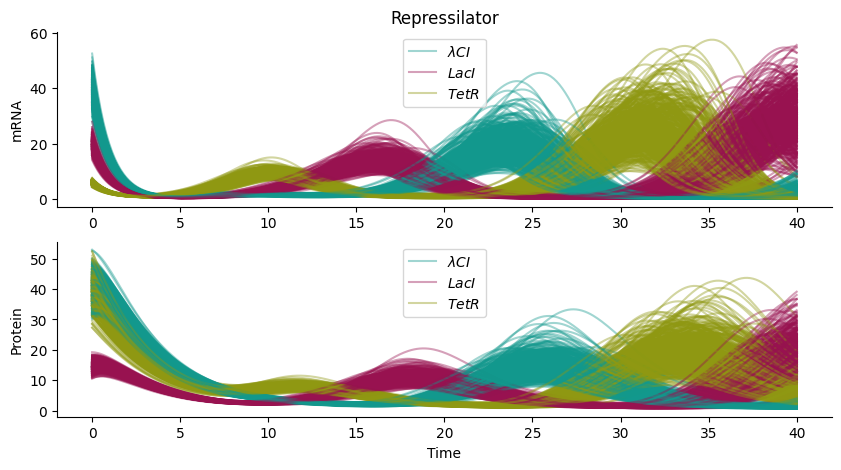

In [243]:
# In case we want a single simulation with the mean
# ths[0] = [1e-1, 70, 0.3, 2]
# y0s[0] = [40, 20, 6, 40, 15, 40]

tspan = (0.0, 40.0) # Initial and final time
teval = np.linspace(tspan[0], tspan[1], 500) # Time vector

start_time = time.perf_counter()
sims = simRep_CPU(ths, y0s, tspan, teval) # Simulation
end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Execution time: {execution_time:.6f} seconds")

plotRepres(teval, sims) # Plot simulation

### Simulate Expanded Model (with GFP)

In [244]:
np.random.seed(42)

N = 500 # Number of samples (theta and y0 together)

thsb = np.zeros((N,10)) # Array for parameters
samp1 = np.random.normal(loc=1e-1, scale=1e-3, size=N) # alpha_0
samp2 = np.random.normal(loc=70, scale=10, size=N) # alpha
samp3 = np.random.normal(loc=0.3, scale=1e-2, size=N) # beta
samp4 = np.random.normal(loc=2, scale=1e-1, size=N) # n
samp5 = np.random.normal(loc=10, scale=3, size=N) # alpha_GFP
samp6 = np.random.normal(loc=1, scale=1e-1, size=N) # kR
samp7 = np.random.normal(loc=0.4, scale=1e-2, size=N) # kM
samp8 = np.random.normal(loc=1, scale=1e-1, size=N) # n2
samp9 = np.random.normal(loc=1, scale=1e-1, size=N) # d1
samp10 = np.random.normal(loc=1e-1, scale=1e-3, size=N) # d2

y0sb = np.zeros((N,8)) # Array for y0
y01 = np.random.normal(loc=40, scale=4, size=N) # mRNA LCI
y02 = np.random.normal(loc=20, scale=2, size=N) # mRNA LacI
y03 = np.random.normal(loc=6, scale=0.6, size=N) # mRNA TetR
y04 = np.random.normal(loc=40, scale=4, size=N) # Protein LCI
y05 = np.random.normal(loc=15, scale=1.5, size=N) # Protein LacI
y06 = np.random.normal(loc=40, scale=4, size=N) # Protein TetR
y07 = abs(np.random.normal(loc=2, scale=0.5, size=N)) # mRNA GFP
y08 = abs(np.random.normal(loc=0, scale=1, size=N)) # Protein GFP

# Put everything together
for i in range(N):
    thsb[i,::] = [samp1[i], samp2[i], samp3[i], samp4[i], samp5[i], samp6[i], samp7[i], samp8[i], samp9[i], samp10[i]]
    y0sb[i,::] = [y01[i], y02[i], y03[i], y04[i], y05[i], y06[i], y07[i], y08[i]]

Execution time: 10.795681 seconds


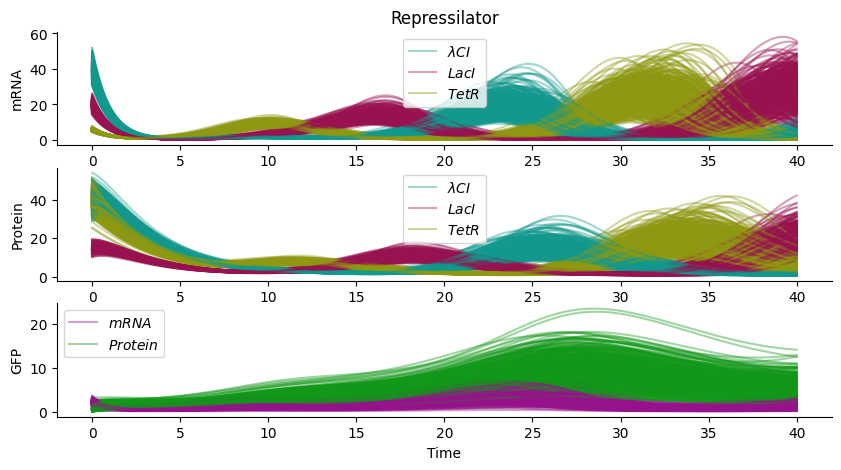

In [245]:
# # In case we want a single simulation with the mean
# thsb[0] = [1e-1, 70, 1, 2,    10, 1, 0.4, 1, 1, 1e-1] #alpha, kR, kM, n, d1, d2
# y0sb[0] = [40, 20, 6, 40, 15, 40,    2, 0]

tspan = (0.0, 40.0) # Initial and final time
teval = np.linspace(tspan[0], tspan[1], 500) # Time vector

start_time = time.perf_counter()
sims = simRep_CPU(thsb, y0sb, tspan, teval) # Simulation
end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Execution time: {execution_time:.6f} seconds")

plotRepres(teval, sims) # Plot simulation

# Simulate Repressilator GPU

### Simulate Original Model (only regulatory components)

In [246]:
np.random.seed(42)

N = 500 # Number of samples (theta and y0 together)
tspan = jnp.array((0.0, 40.0))
teval = np.linspace(tspan[0], tspan[1], 500)


ths = np.zeros((N,4)) # Array for parameters
samp1 = np.random.normal(loc=1e-1, scale=1e-3, size=N) # alpha_0
samp2 = np.random.normal(loc=70, scale=10, size=N) # alpha
samp3 = np.random.normal(loc=0.3, scale=1e-2, size=N) # beta
samp4 = np.random.normal(loc=2, scale=1e-1, size=N) # n

y0s = np.zeros((N,6)) # Array for y0
y01 = np.random.normal(loc=40, scale=4, size=N) # mRNA LCI
y02 = np.random.normal(loc=20, scale=2, size=N) # mRNA LacI
y03 = np.random.normal(loc=6, scale=0.6, size=N) # mRNA TetR
y04 = np.random.normal(loc=40, scale=4, size=N) # Protein LCI
y05 = np.random.normal(loc=15, scale=1.5, size=N) # Protein LacI
y06 = np.random.normal(loc=40, scale=4, size=N) # Protein TetR

# Put everything together
for i in range(N):
    ths[i,::] = [samp1[i], samp2[i], samp3[i], samp4[i]]
    y0s[i,::] = [y01[i], y02[i], y03[i], y04[i], y05[i], y06[i]]

batch_params = jnp.array(ths)
batch_y0 = jnp.array(y0s)

Execution time: 2.702315 seconds


c:\Users\david\anaconda3\envs\jax\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


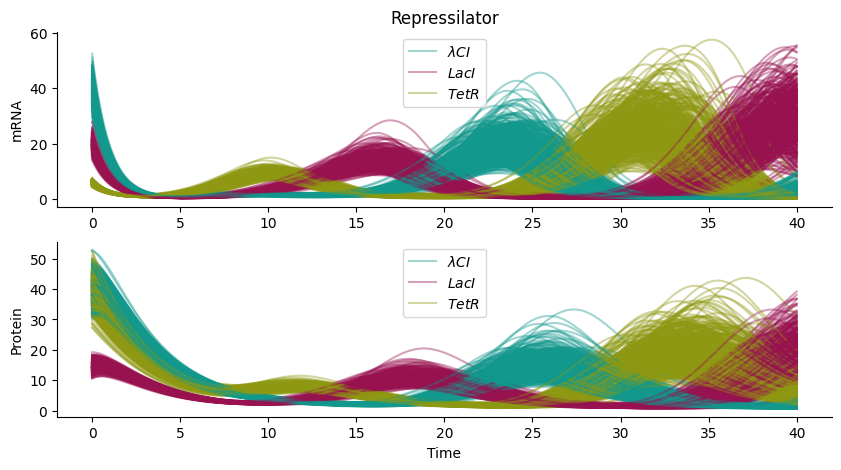

In [247]:
aa = run_batch(batch_params[0:2,::], batch_y0[0:2,::], tspan)
start_time = time.perf_counter()

results = run_batch(batch_params, batch_y0, tspan)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Execution time: {execution_time:.6f} seconds")

plotRepres(teval, results)

### Simulate Expanded Model (with GFP)

In [248]:
np.random.seed(42)

N = 500 # Number of samples (theta and y0 together)
tspan = jnp.array((0.0, 40.0))
teval = np.linspace(tspan[0], tspan[1], 500)


thsb = np.zeros((N,10)) # Array for parameters
samp1 = np.random.normal(loc=1e-1, scale=1e-3, size=N) # alpha_0
samp2 = np.random.normal(loc=70, scale=10, size=N) # alpha
samp3 = np.random.normal(loc=0.3, scale=1e-2, size=N) # beta
samp4 = np.random.normal(loc=2, scale=1e-1, size=N) # n
samp5 = np.random.normal(loc=10, scale=3, size=N) # alpha_GFP
samp6 = np.random.normal(loc=1, scale=1e-1, size=N) # kR
samp7 = np.random.normal(loc=0.4, scale=1e-2, size=N) # kM
samp8 = np.random.normal(loc=1, scale=1e-1, size=N) # n2
samp9 = np.random.normal(loc=1, scale=1e-1, size=N) # d1
samp10 = np.random.normal(loc=1e-1, scale=1e-3, size=N) # d2

y0sb = np.zeros((N,8)) # Array for y0
y01 = np.random.normal(loc=40, scale=4, size=N) # mRNA LCI
y02 = np.random.normal(loc=20, scale=2, size=N) # mRNA LacI
y03 = np.random.normal(loc=6, scale=0.6, size=N) # mRNA TetR
y04 = np.random.normal(loc=40, scale=4, size=N) # Protein LCI
y05 = np.random.normal(loc=15, scale=1.5, size=N) # Protein LacI
y06 = np.random.normal(loc=40, scale=4, size=N) # Protein TetR
y07 = abs(np.random.normal(loc=2, scale=0.5, size=N)) # mRNA GFP
y08 = abs(np.random.normal(loc=0, scale=1, size=N)) # Protein GFP

# Put everything together
for i in range(N):
    thsb[i,::] = [samp1[i], samp2[i], samp3[i], samp4[i], samp5[i], samp6[i], samp7[i], samp8[i], samp9[i], samp10[i]]
    y0sb[i,::] = [y01[i], y02[i], y03[i], y04[i], y05[i], y06[i], y07[i], y08[i]]

batch_params2 = jnp.array(thsb)
batch_y02 = jnp.array(y0sb)

Execution time: 3.113921 seconds


c:\Users\david\anaconda3\envs\jax\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


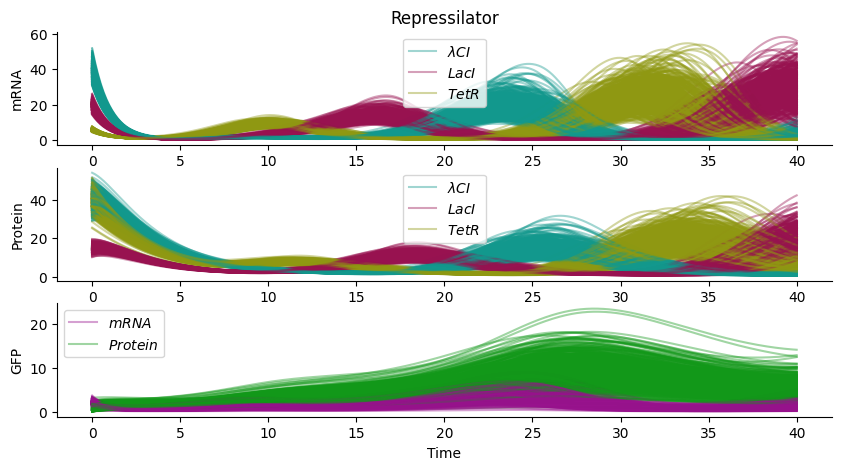

In [249]:
aa = run_batch_GFP(batch_params2[0:2,::], batch_y02[0:2,::], tspan)
start_time = time.perf_counter()

results = run_batch_GFP(batch_params2, batch_y02, tspan)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Execution time: {execution_time:.6f} seconds")

plotRepres(teval, results)